#EDA Part of project

In [21]:
import os
os.makedirs("plot", exist_ok=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
import pandas as pd

data = pd.read_csv(r"c:\Users\sumit\Downloads\processed_data.csv")
df=pd.DataFrame(data)
df.head(10)


,tag,pattern,response,pattern_length,response_length
0,greeting,Hi,Hello! How can I assist you with Medical Assis...,1,10
1,greeting,Hello,Hello! How can I assist you with Medical Assis...,1,10
2,greeting,Hey,Hello! How can I assist you with Medical Assis...,1,10
3,greeting,Greetings,Hello! How can I assist you with Medical Assis...,1,10
4,cancer_general,What is cancer?,Cancer is a group of diseases characterized by...,3,40
5,cancer_general,Tell me about cancer,Cancer is a group of diseases characterized by...,4,40
6,cancer_general,Explain cancer types,Cancer is a group of diseases characterized by...,3,40
7,cancer_general,How does cancer develop?,Cancer is a group of diseases characterized by...,4,40
8,cancer_types,Tell me about lung cancer,"Cancer types include lung cancer, breast cance...",5,21
9,cancer_types,What are the types of breast cancer?,"Cancer types include lung cancer, breast cance...",7,21


In [11]:


df.head()
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   tag              98 non-null     str  
 1   pattern          98 non-null     str  
 2   response         98 non-null     str  
 3   pattern_length   98 non-null     int64
 4   response_length  98 non-null     int64
dtypes: int64(2), str(3)
memory usage: 38.4 KB


np.int64(0)

In [12]:
df['tag'].value_counts()

tag
cancer_types               5
cancer_symptoms            5
cancer_prevention          5
diabetes_types             5
diabetes_prevention        5
alzheimers_types           5
alzheimers_symptoms        5
alzheimers_prevention      5
hypertension_types         5
hypertension_prevention    5
stroke_types               5
stroke_prevention          5
greeting                   4
cancer_general             4
diabetes_general           4
diabetes_symptoms          4
alzheimers_general         4
hypertension_general       4
stroke_general             4
send_off                   4
hypertension_symptoms      3
stroke_symptoms            3
Name: count, dtype: int64

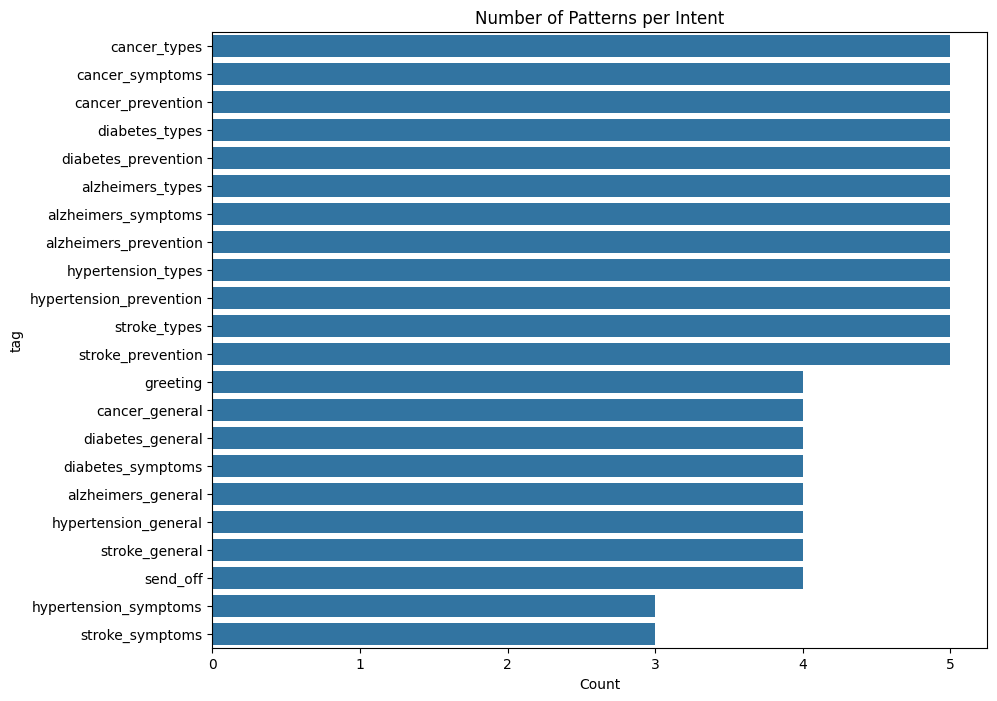

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.barplot(x=df['tag'].value_counts().values, y=df['tag'].value_counts().index)
plt.title("Number of Patterns per Intent")
plt.xlabel("Count")

plt.savefig("plot/tag_distribution.png", bbox_inches='tight', dpi=150)
plt.show()


#  Text Length Analysis
Examining how long the user queries (patterns) and bot replies (responses) are, using the pre-computed `pattern_length` and `response_length` columns.

In [14]:
df[['pattern_length', 'response_length']].describe()

,pattern_length,response_length
count,98.000000,98.000000
mean,8.122449,43.561224
std,6.498636,24.176783
min,1.000000,10.000000
25%,4.000000,25.750000
50%,6.000000,35.000000
75%,10.000000,67.750000
max,29.000000,87.000000


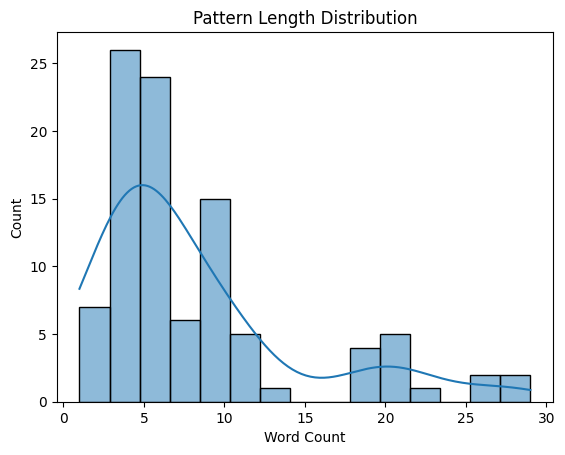

In [25]:
sns.histplot(df['pattern_length'], bins=15, kde=True)
plt.title("Pattern Length Distribution")
plt.xlabel("Word Count")

plt.savefig("plot/pattern_length.png", bbox_inches='tight', dpi=150)
plt.show()

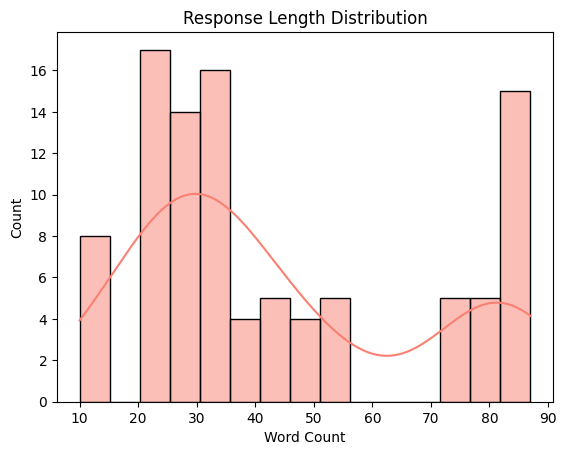

In [26]:
sns.histplot(df['response_length'], bins=15, kde=True, color="salmon")
plt.title("Response Length Distribution")
plt.xlabel("Word Count")
plt.savefig("plot/response_length_distribution.png", bbox_inches='tight', dpi=150)
plt.show()

#  Most Frequent Words in Patterns
Finding common vocabulary in user queries — useful for the NLP/modeling team to understand phrasing diversity.

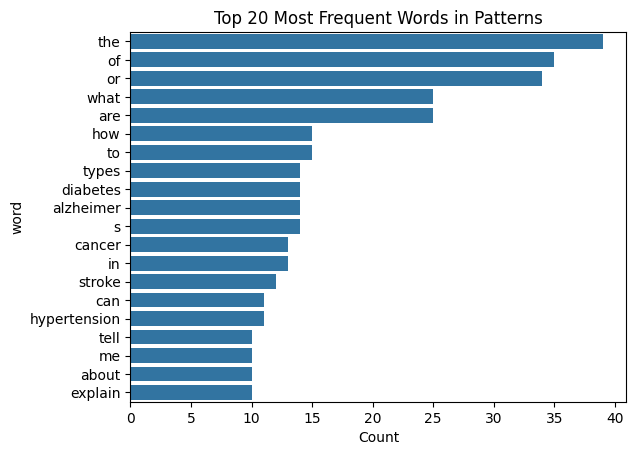

In [28]:
from collections import Counter
import re

words = re.findall(r'\b[a-z]+\b', ' '.join(df['pattern']).lower())
top_words = Counter(words).most_common(20)
top_df = pd.DataFrame(top_words, columns=['word','count'])

sns.barplot(data=top_df, x='count', y='word')
plt.title("Top 20 Most Frequent Words in Patterns")
plt.xlabel("Count")

plt.savefig("plot/top_words.png", bbox_inches='tight', dpi=150)
plt.show()

#  Summary of Findings
- Dataset has 98 rows, 22 intents, no missing values or duplicates.
- Intent distribution is slightly imbalanced (3–5 examples per intent).
- Average pattern length and response length noted above.
- Most frequent words identified above — useful for understanding query phrasing patterns.